# Toy Example for RUV-VAE / scVI

## Design

- **Conditions**: A, B, C, D
- **Batches**: 1, 2, 3, 4
- **Features** per cell: 2 (`gene1`, `gene2`)

Cell counts per condition × batch:

|         | batch_1 | batch_2 | batch_3 | batch_4 |
|---------|:-------:|:-------:|:-------:|:-------:|
| **A**   |   30    |   30    |   30    |    -    |
| **B**   |   30    |   30    |   30    |    -    |
| **C**   |    -    |    -    |   30    |    -    |
| **D**   |    -    |    -    |   30    |    -    |

So:
- **A** and **B** span batches 1, 2, 3 → they can act as *anchors* for batch-effect estimation.
- **C** and **D** live only in batch 3 → they are *batch-confounded* with respect to any other condition in batch 3 (i.e. you cannot separate their condition effect from the batch-3 shift using only batch-3 cells, you need the A/B anchors across batches).

## Generative model

`y = condition_effect + batch_effect + noise`

- condition means (2D): A=(0,0), B=(3,0), C=(0,3), D=(3,3)
- additive batch shifts (2D): b1=(0,0), b2=(1, 0.5), b3=(0.5, 1)
- noise: `N(0, 0.3²)` per feature

The "true" condition effect on each gene is recoverable once the batch effect has been estimated (e.g. by RUV or scVI with batch as a covariate).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata

rng = np.random.default_rng(42)

In [7]:
# ----- design -----
conditions = ['A', 'B', 'C', 'D']
batches    = [1, 2, 3, 4]

# cells per (condition, batch)
n_cells_map = {
    ('A', 1): 30, ('A', 2): 30, ('A', 3): 30,
    ('B', 1): 30, ('B', 2): 30, ('B', 3): 30,
    ('C', 3): 30,
    ('D', 3): 30,
}

# true condition means in 2D
cond_mean = {
    'A': np.array([0.0, 0.0]),
    'B': np.array([3.0, 0.0]),
    'C': np.array([0.0, 3.0]),
    'D': np.array([3.0, 3.0]),
}

# additive batch shifts in 2D
batch_shift = {
    1: np.array([0.0, 0.0]),
    2: np.array([1.0, 1.5]),
    3: np.array([0.5, 1.5]),
    4: np.array([0.0, 0.0]),   # unused
}

noise_std = 0.3

# ----- sample -----
records = []
for (cond, batch), n in n_cells_map.items():
    mean = cond_mean[cond] + batch_shift[batch]
    X = rng.normal(loc=mean, scale=noise_std, size=(n, 2))
    for i in range(n):
        records.append({
            'cell_id':   f'{cond}_b{batch}_{i:03d}',
            'condition': cond,
            'batch':     f'batch_{batch}',
            'batch_num': batch,
            'gene1':     X[i, 0],
            'gene2':     X[i, 1],
        })

df = pd.DataFrame(records)
print(f"Total cells: {len(df)}")
df.head()

Total cells: 240


,cell_id,condition,batch,batch_num,gene1,gene2
0,A_b1_000,A,batch_1,1,0.091415,-0.311995
1,A_b1_001,A,batch_1,1,0.225135,0.282169
2,A_b1_002,A,batch_1,1,-0.585311,-0.390654
3,A_b1_003,A,batch_1,1,0.038352,-0.094873
4,A_b1_004,A,batch_1,1,-0.005040,-0.255913


In [8]:
summary = (
    df.groupby(['condition', 'batch'])
      .size()
      .unstack(fill_value=0)
      .reindex(index=conditions,
               columns=[f'batch_{b}' for b in batches],
               fill_value=0)
)
summary

batch,batch_1,batch_2,batch_3,batch_4
condition,,,,
A,30,30,30,0
B,30,30,30,0
C,0,0,30,0
D,0,0,30,0


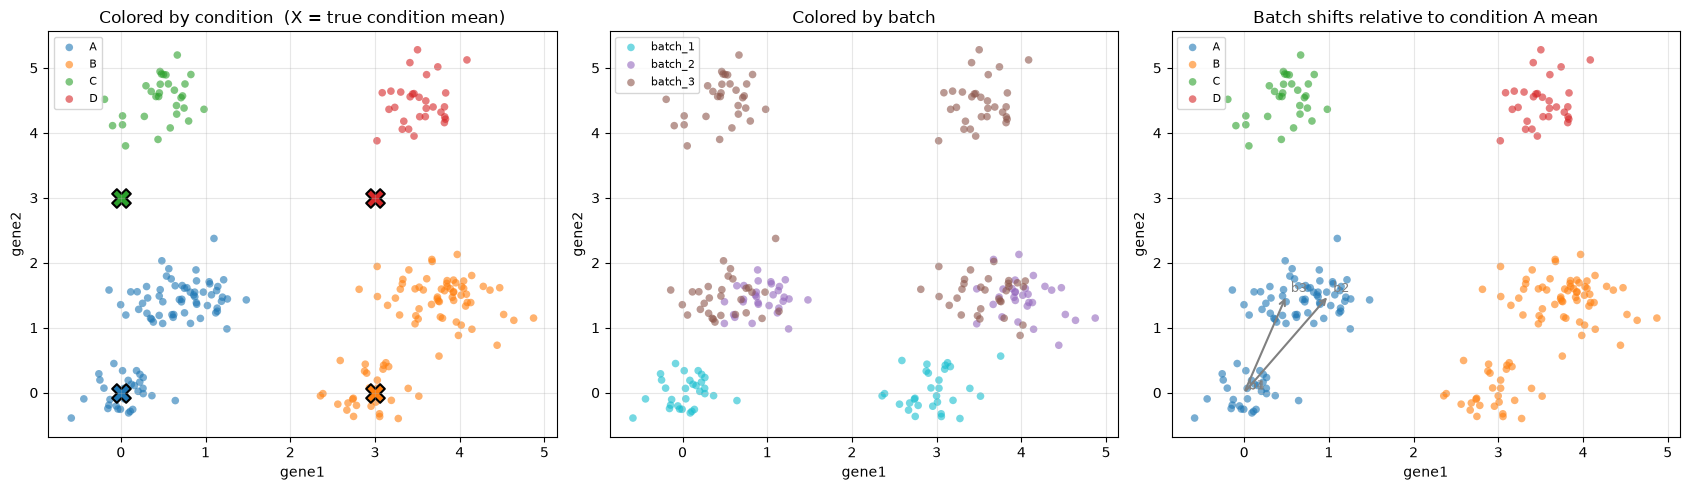

In [9]:
cond_colors  = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728'}
batch_colors = {1: '#17becf', 2: '#9467bd', 3: '#8c564b', 4: '#e377c2'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- panel 1: colored by condition, with true condition means ---
for cond in conditions:
    sub = df[df['condition'] == cond]
    axes[0].scatter(sub['gene1'], sub['gene2'], c=cond_colors[cond],
                    label=cond, alpha=0.6, s=30, edgecolors='none')
for cond, m in cond_mean.items():
    axes[0].scatter(m[0], m[1], c=cond_colors[cond], marker='X', s=180,
                    edgecolors='black', linewidths=1.5)
axes[0].set_title('Colored by condition  (X = true condition mean)')
axes[0].set_xlabel('gene1'); axes[0].set_ylabel('gene2')
axes[0].legend(loc='upper left', fontsize=8); axes[0].grid(alpha=0.3)

# --- panel 2: colored by batch ---
for b in batches:
    sub = df[df['batch_num'] == b]
    if len(sub) == 0:
        continue
    axes[1].scatter(sub['gene1'], sub['gene2'], c=batch_colors[b],
                    label=f'batch_{b}', alpha=0.6, s=30, edgecolors='none')
axes[1].set_title('Colored by batch')
axes[1].set_xlabel('gene1'); axes[1].set_ylabel('gene2')
axes[1].legend(loc='upper left', fontsize=8); axes[1].grid(alpha=0.3)

# --- panel 3: how batch shifts move the A cluster ---
for cond in conditions:
    sub = df[df['condition'] == cond]
    axes[2].scatter(sub['gene1'], sub['gene2'], c=cond_colors[cond],
                    label=cond, alpha=0.6, s=30, edgecolors='none')
# draw batch-shift arrows starting from condition A mean
for b, s in batch_shift.items():
    axes[2].annotate('', xy=cond_mean['A'] + s, xytext=cond_mean['A'],
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    axes[2].text(*(cond_mean['A'] + s + np.array([0.05, 0.05])),
                 f'b{b}', fontsize=9, color='gray')
axes[2].set_title('Batch shifts relative to condition A mean')
axes[2].set_xlabel('gene1'); axes[2].set_ylabel('gene2')
axes[2].legend(loc='upper left', fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
adata = anndata.AnnData(
    X=df[['gene1', 'gene2']].values.astype(np.float32),
    obs=df[['cell_id', 'condition', 'batch', 'batch_num']].set_index('cell_id'),
    var=pd.DataFrame(index=['gene1', 'gene2']),
)

# store raw counts for scVI (here counts == normalized because toy is small)
adata.layers['counts'] = adata.X.copy()

# ground-truth batch effect per cell, useful for sanity checks
adata.obsm['X_true_cond']    = np.array([cond_mean[c] for c in adata.obs['condition']])
adata.obsm['X_true_batch']   = np.array([batch_shift[b] for b in adata.obs['batch_num']])
adata.obsm['X_true_latent']  = adata.obsm['X_true_cond'] + adata.obsm['X_true_batch']

print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 240 × 2
    obs: 'condition', 'batch', 'batch_num'
    obsm: 'X_true_cond', 'X_true_batch', 'X_true_latent'
    layers: None (.X), 'counts'


,condition,batch,batch_num
cell_id,,,
A_b1_000,A,batch_1,1
A_b1_001,A,batch_1,1
A_b1_002,A,batch_1,1
A_b1_003,A,batch_1,1
A_b1_004,A,batch_1,1


## What to do with this toy

This `adata` is ready to feed into scVI / scvi-tools / RUV-VAE as a 2-feature dataset:

```python
import scvi
scvi.model.SCVI.setup_anndata(adata, batch_key='batch', layer='counts')
model = scvi.model.SCVI(adata)
model.train()
```

A few useful sanity checks you can run after training:

- `adata.obsm['X_scVI']` should look like `X_true_latent` after subtracting the per-batch shift.
- Differential expression between `A` vs `C` (both in batch 3) is confounded by the batch-3 shift unless you condition on `batch` (or use RUV-style negative controls). Comparing `A` (b1) vs `C` (b3) is *not* confounded.
- Because A and B each span batches 1/2/3, they can be used to *estimate* the batch-3 shift, which can then be removed from C and D.